# Logistic Regression

# 1. Giới thiệu

Nhắc lại 2 mô hình tuyến tính

Hai mô hình tuyến tính (linear models) Linear Regression và Perception Learning Algorthm (PLA) chúng ta đã biết đều có chung 1 dạng:
$$
y = f(w^T.x)
$$

trong đó $f()$ được gọi là activation function, và $x$ được hiểu là dữ liệu mở rộng với $x_0 = 1$ đưcoj thêm vào để thuântj tiện cho việc tính toán. Với linear Regression thì $f(s) = s$, với PLA thì $f(s) = sgn(s)$.

Trong Linear Regression, tích vô hướng $w^T.x$ đưcoj trực tiếp sử dụng để dự đoán output $y$, loại này phù hợp nếu chúng ta cần dự đoán một giá trị thực của đầu ra không bị chặn trên và dưới. Trong PLA, đầu ra chỉ nhận một trong 2 giá trị $1$ hoặc $-1$, phù hợp với các bài toán binary classification.

Trong bài này, tôi sẽ giới thiệu mô hình thứ 3 với một activation khác, được sử dụng cho bài toán flexible hơn. Trong dạng này, đầu ra có thể được thể hiện dưới dạng xác suất (probability).

Ví dụ: xác suất thi đỗ nếu biết thời gian ôn thi, xác suất ngày mai có mưa dựa trên những thông tin đo được trong ngày hôm nay,... Mô hình mới này của chúng ta có tên là $\text{logistic regression}$. Mô hình này giống với linear regression ở khía cạnh đầu ra là số thực, và giống với PLA ở việc đầu ra bị chặn (trong đoạn $[0,1]$). Mặc dù trong tên có chứa từ $regression$, logistic regression thường được sử dụng nhiều hơn cho các bài toán classificaiton.

##### Một ví dụ nhỏ

TÔi xin được sử dụng một ví dụ trên Wikipedia:

Một nhóm 20 sinh viên dành thời gian trong khoảng từ 0 đến 6 giờ cho việc ôn thi. Thời gian ôn thi này ảnh hưởng đến xác suất sinh viên vượt qua kỳ thi như thế nào?

Kết quả thu được như sau:

![](image1.png)

Mặc dù có một chút bất công khi học 3.5 giờ thì trượt, còn học 1.75 giờ thì lại đỗ, nhìn chung, học càng nhiều thì khả năng đỗ càng cao. PLA không thể áp dụng được cho bài toán này vì không thể nói một người học bao nhiêu giờ thì 100% trượt hay đỗ, và thực tế là dữ liệu này cũng không linearly separable (điệu kiện để PLA có thể làm việc). Chú ý rằng các điểm màu đỏ và xanh được vẽ ở hai tung độ khác nhau để tiện cho việc minh họa. Các điểm này được vẽ dùng cả dữ liệu đầu vào $x$ và đầu ra $y$. Khi ta nói linearly seperable là khi ta chỉ dùng dữ liệu đầu vào $x$.

Chúng ta biểu diễn các điểm này trên đồ thị để thấy rõ hơn:

![](image2.png)

Nhận thấy rằng cả linear regression và PLA đều không phù hợp với bài toán này, chúng ta cần một mô hình flexible hơn.

## Mô hình Logistic Regression

Đầu ra dự doán của:

- Linear Regression: 
$$
f(x) = w^T.x
$$

- PLA:
$$
f(x) = sgn(w^T.x)
$$

- Đầu ra dự đoán của logistic regression thườngd dưcoj viết chung dưới dạng:
$$
f(x) = \theta(w^T.x)
$$
Trong đó $\theta$ được gọi là logistic function. Một số activation cho mô hình tuyến tính được cho trong hình dứoi đây:


![](image3.png)

- Đường màu vàng: biểu diễn linear regression. Đường này không bị chặn nên không phù hợp cho bài toán này. Có một trick nhỏ để đưa về dạng bị chặn: cắt phần nhỏ hơn 0 bằng cách cho chúng bằng $0$, cắt các phần lớn hơn $1$ bằng cách cho chúng bằng $1$. Sau đó lấy điểm trên đường thẳng này có tung độ bằng $0.5$ làm điểm phân chia 2 class, đây cũng không phải lựa chọn tốt. Giả sử có thêm vài bạn sinh viên tiêu biểu ôn tập đến 20 giờ và, tất nhiên, thì đỗ. Khi áp dụng mô hình linear regression như hình dưới đây và lấy mốc $0.5$ để phân lớp, toàn bộ sinh viên thi trượt vẫn được dự đoán là trượt, nhưng rất nhiều sinh viên thi đỗ cũng được dự đoán là trượt (nếu ta coi điểm x màu xanh lục là ngưỡng cứng để đưa ra kết luận). Rõ ràng đây là một mô hìnhkhoong ôtts. Anh chàng sinh viên tiêu biểu này đã kéo theo rất nhiều bạn khác bị trượt.

![](image4.png)

- Đường màu đỏ: chỉ khác với activation function của PLA ở chuỗi 2 class 0 và 1 thay vì -1 và 1, cũng thuộc dạng ngưỡng cứng (hard threshold). PLA không hoạt động trong bài toán này vì dữ liệu đã không linearly separable.
- Các đường màu xanh lam và lục: hợp với bài toán của chúng ta hơn. Chúng có một vài tính chất quan trọng sau:
    - Là hàm số liên tục nhận giá tị thực, bị chặn trong khoảng (0,1).
    - Nếu coi điểm có tung độ là 1/2. làm điểm phân chia thì các điểm càng xa điểm này về phía bên trái có giá trị càng gần 0. Ngược lại, các điểm càng xa điểm này về phía phải có giá trị càng gần 1. Điều này khớp với nhận xét rằng học càng nhiều hti xác suất đỗ càng cao và ngược lại.
    - Mượt (smooth) nên có đạo hàm mọi nơi, có thể được lợi trong việc tối ưu. 

## Sigmoid Function

Trong số các hàm số có 3 tính chất nói trên thì hàm sigmoid:
$$
f(s) = \frac{1}{1 + e^{-s}} = \sigma(s)
$$

được sử dụng nhiều nhất, vì nó bị chặn trong khoảng (0,1). Thêm nữa:
$$
\lim_{s \rightarrow -∞}{\sigma(s) = 0}
$$
$$
\lim_{s \rightarrow +∞}{\sigma(s) = 1}
$$

Đặc biệt hơn nữa:
$$
\sigma^{'}(s) = \frac{e^{-s}}{(1 + e^{-s})^2} \\
= \frac{1}{1 + e^{-s}}.\frac{e^{-s}}{1 + e^{-s}} \\
= \sigma(s).(1 - \sigma(s))
$$

Công thức đạo hàm đơn giản thế này giúp hàm số này được sử dụng rộng rãi. Ở phần sau, tôi sẽ lý giải việc người ta đã tìm ra hàm số đặc biệt này như thế nào

Ngoài ra, hàm $tanh$ cũng hay được sử dụng:
$$
tanh(s) = \frac{e^s - e^{-s}}{e^s + e^{-s}}
$$

Hàm số này nhận giá trị khoảng $(-1, 1)$, nhưng có thể dễ dàng đưa nó về khoảng $(0,1)$. Bạn đọc có thể chứng minh được:
$$
tanh(s) = 2\sigma.(2s) - 1
$$

# 2. Hàm mất mát và phương pháp tối ưu

### Xây dựng hàm mất mát

Với mô hình như trên (các activation màu xanh lam và lục), ta có thể giả sử rằng xác suất để một điểm dữ liệu $x$ rời vào class $1$ là $f(w^T.x)$ và rơi vào class $0$ là $(1 - f(w^T.x))$.

Với mô hình được giả sử như vậy, với các điểm dữ liệu traning (đã biết đầu ra $y$), ta có thể viết như sau:
$$
P(y_i = 1 | x_i; w) = f(w^T.x_i) \space (1) \\
P(y_i = 0 | x_i; w) = 1 - f(w^T.x_i) \space (2)
$$

trong đó $P(y_i = 1 | x_i; w)$ đưcoj hiểu là xác suât xảy ra sự kiện đầu ra $y_i = 1$ khi biết tham số mô hình $w$ và dữ liệu đầu vào $x_i$. Bạn đọc có thể đọc thêm Xác suất có điều kiện. Mục đích của chúng ta là tìm các hệ số $w$ sao cho $f(w^T.x_i)$ càng gần với $1$ càng tốt với các điểm dữ liệu thuộc class $1$ và càng gần với $0$ càng tốt với những điểm thuộc class $0$.

Ký hiệu $z_i = f(w^T.x_i)$ và viết gộp lại 2 biểu thức bên trên ta có:
$$
P(y_i | x_i; w) = z_i^{y_i}(1 - z_i)^{1 - y_i}
$$

Biểu thức này là tương đương với 2 biểu thức $(1)$ và $(2)$ ở trên vì khi $y_i = 1$, phần thứ 2 của vế phải sẽ triệt tiêu, khi $y_i = 0$, phần thứ nhất sẽ bị triệt tiêu! Chúng ta muốn mô hình gần với dữ liệu đã cho nhất, tức xác suất này đạt gía trị cao nhất.

Xét toàn bộ training set với $X = [x_1,x_2,...,x_n] \in R^{d\times N}$ và $y = [y_1,y_2,...,y_N]$, chúng ta cần tìm $w$ để biểu thức sau đây đạt giá trị lớn nhất:
$$
P(y | X; w)
$$

ở đây, ta cũng ký hiệu $X,y$ như các biến ngẫu nhiên (random variables). Nói cách khác:
$$
w = \arg\space \max_{w}{P(y|X; w)}
$$

Bài toán tìm tham số để mô hình gần với dữ liệu nhất trên đây có tên gọi chung là bài toán $\text{maximum likelihood estimation}$ với hàm số phía sau $\arg\max$ được gọi là $\text{likelihood function}$. Khi làm việc với các bài toán Machine Learning sử dụng các mô hình xác suất thống kê, chúng ta sẽ gặp lại các bài toán thuộc dạng này, hoặc maximum a posteriori estimation, rất nhiều. Tôi sx dành bài khác để nói về 2 dạng bài toán này.

Giả sử thêm rằng các điểm dữ liệu được sinh ra một cách ngẫu nhiên độc lập với nhau (independent), ta có thể viết:
$$
P(y|X; w) = ∏_{i=1}^{N} P(y_i|x_i; w) \\
= ∏_{i=1}^N z_{i}^{y_i}.(1 - z_i)^{1 - y_i}
$$

với $∏$ là ký hiệu của tích. Bạn đọc có thể muốn đọc thêm về Độc lập thống kê.

Trực tiếp tối ưu hàm số này theo $w$ nhìn qua không đơn giản! Hơn nữa, khi $N$ lớn, tích của $N$ số nhỏ hơn $1$ có thể dẫn tới sai số trong tính toán (numerial error) vì tích là một số quá nhỏ.

Một phương pháp thường được sử dụng đó là lấy logarit tự nhiên (cơ số $e$) của likelihood function biến phép nhân thành phép cộng và để tránh việc số quá nhỏ. Sau đó lấy ngược dấu để được một hàm và coi nó là hàm mất mát. Lúc này bài toán tìm giá trị lớn nhất (maximum likelihood) trở thành bài toán tìm giá trị nhỏ nhất của hàm mất mát (hàm này còn được gọi là negative log likelihood):
$$
J(w) = -\log{P(y | X; w)} \\
= - \sum_{i = 1}^{N}{(y_i.\log{z_i} + (1 - y_i).\log(1 - z_i)}
$$

với chú ý rằng $z_i$ là một hàm số của $w$. Bạn đọc tạm nhớ biểu thức vế phải có tên gọi là $\text{cross entropy}$, thường được sử dụng để đo khoảng cách giữa 2 phân phối (distributions). Trong bài toán đang xét, một phân phối là dữ liệu được cho, với xác suất chỉ là $0$ hoặc $1$, phân phối còn lại được tính theo mô hình logistic regression. Khoảng cách giữa hai phân phối nhỏ đồng nghĩa với việc (có vẻ hiển nhiên là) hai phân phối đó rất gần nhau. TÍnh chất cụ thể của hàm số này sẽ được đề cập trong một bài toán khác mà tầm quan trọng của khoảng cách giữa 2 phân phối là lớn hơn.

Chú ý: Trong machine learning, logarit thập phân ít được dùng, vì vậy 
log
 thường được dùng để ký hiệu logarit tự nhiên

### Tối ưu hàm mất mát

Chúng ta lại được sử dụng pp $\text{Stochastic Gradient Descent}$ (SGD) ở đây (bạn đọc khuyến khcish đọc SGD trước khi đọc phần này). Hàm mất mát với chỉ một điểm dữ liệu $(x_i, y_i)$ là:
$$
J(w;x_i,y_i) = -(y_i.\log{z_i} + (1 - y_i).\log{(1 - z_i)})
$$

với đạo hàm:

$$
\frac{\partial J(w;x_i,y_i)}{\partial w} = -(\frac{y_i}{z_i} - \frac{1 - y_i}{1 - z_i}).\frac{\partial z_i}{\partial w} = \frac{z_i - y_i}{z_i.(1 - z_i)}.\frac{\partial z_i}{\partial w} \space (3)
$$

Để cho biểu thức này trở nên gọn và đẹp hơn, chúng ta sẽ tìm hàm $z = f(w^T.x)$ sao cho mẫu số bị triệt tiêu. Nếu đặt $s = w^T.x$, chúng ta sẽ có:
$$
\frac{\partial z_i}{\partial w} = \frac{\partial z_i}{\partial s}.\frac{\partial s}{\partial w} = \frac{\partial z_i}{\partial s}.x
$$

Một cách trực quan nhất, ta sẽ tìm hàm số $z = f(s)$ sao cho:
$$
\frac{\partial z}{\partial s} = z(1 - z) \space (4)
$$

để triệt tiêu mẫu số biểu thức $(3)$, chúng ta cùng khởi động một chút với phương tình vi phân đơn giản này. Phương trình $(4)$ tương đương với:
$$
\frac{\partial z}{z(1 - z)} = \partial s \\
⇔ (\frac{1}{z} + \frac{1}{1 - z}.\partial z) = \partial s \\
⇔ \log(z) - \log(1 - z) = s \\
⇔ \log{frac{z}{1 - z}} = s \\
⇔ \frac{z}{1 - z} = e^s \\
⇔ z = e^s.(1 - z) \\
⇔ z = \frac{e^s}{1 + e^s} = \frac{1}{1 + e^{-s}} = \sigma(s)
$$

Đến đây, tôi hy vọng các bạn đã hiểu hàm số $sigmoid$ được tạo ra như thế nào.

Chú ý: Trong việc giải phương trình vi phân ở trên, tôi đã bỏ qua hằng số khi lấy nguyên hàm hai vế. Tuy vậy, việc này không ảnh hưởng nhiều tới kết quả

### Công thức cập nhật cho logistic sigmoid regression

Tới đây, bạn đọc có thể kiểm tra rằng:
$$
\frac{\partial J(w;x_i,y_i)}{\partial w} = (z_i - y_i).x_i
$$

Qúa đẹp!

Và công thức cập nhật (theo thuật toán SGD) cho logistic regression là:
$$
w = w + \eta (y_i - z_i).x_i
$$

Khá đơn giản! Và, như thường lệ, chúng ta sẽ có vài ví dụ với Python.

# 3. Ví dụ với Python

Ví dụ với dữ liệu 1 chiều

Quay trở lại với ví dụ nêu ở phần Giới thiệu. Trước tiên ta cần khai báo vài thư viện và dữ liệu:



In [1]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals
import numpy as np 
import matplotlib.pyplot as plt

np.random.seed(2)

X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50, 
              2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# extended data 
X = np.concatenate((np.ones((1, X.shape[1])), X), axis = 0)

Các hàm cần thiết cho logistic sigmoid regression

In [2]:
def sigmoid(s):
    return 1/(1 + np.exp(-s))

In [3]:
def logistic_sigmoid_regression(X, y, w_init, eta, tol = 1e-4, max_count = 10000):
    w = [w_init]    
    it = 0
    N = X.shape[1]
    d = X.shape[0]
    count = 0
    check_w_after = 20
    while count < max_count:
        # mix data 
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:, i].reshape(d, 1)
            yi = y[i]
            zi = sigmoid(np.dot(w[-1].T, xi))
            w_new = w[-1] + eta*(yi - zi)*xi
            count += 1
            # stopping criteria
            if count%check_w_after == 0:                
                if np.linalg.norm(w_new - w[-check_w_after]) < tol:
                    return w
            w.append(w_new)
    return w

In [4]:
eta = .05 
d = X.shape[0]
w_init = np.random.randn(d, 1)

w = logistic_sigmoid_regression(X, y, w_init, eta)
print(w[-1])

[[-4.092695  ]
 [ 1.55277242]]


[[-4.092695  ]
 [ 1.55277242]]

Với kết quả tìm được, đầu ra $y$ có thể được dự đoán theo công thức: y = sigmoid(-4.1 + 1.55*x). Với dữ liệu trong tập training, kết quả là:

In [5]:
print(sigmoid(np.dot(w[-1].T, X)))

[[0.03501592 0.05078108 0.07310642 0.10416972 0.14634799 0.20175793
  0.20175793 0.27147534 0.35458234 0.4475032  0.54424128 0.63775242
  0.72188183 0.79282004 0.89267823 0.92460236 0.94758783 0.96384008
  0.97518471 0.9884283 ]]


[[ 0.03281144  0.04694533  0.06674738  0.09407764  0.13102736  0.17961209
   0.17961209  0.24121129  0.31580406  0.40126557  0.49318368  0.58556493
   0.67229611  0.74866712  0.86263755  0.90117058  0.92977426  0.95055357
   0.96541314  0.98329067]]

Biểu diễn kết quả này trên đồ thị ta có:

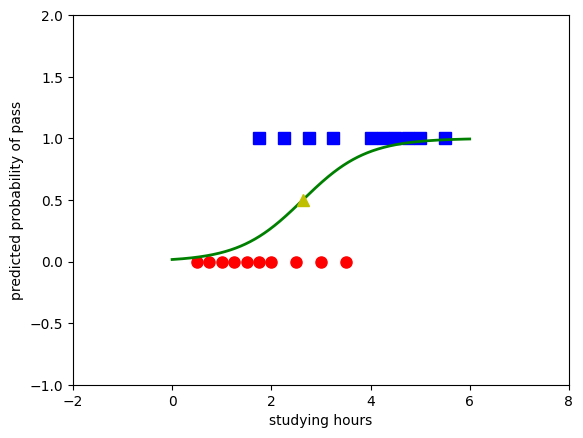

In [6]:
X0 = X[1, np.where(y == 0)][0]
y0 = y[np.where(y == 0)]
X1 = X[1, np.where(y == 1)][0]
y1 = y[np.where(y == 1)]

plt.plot(X0, y0, 'ro', markersize = 8)
plt.plot(X1, y1, 'bs', markersize = 8)

xx = np.linspace(0, 6, 1000)
w0 = w[-1][0][0]
w1 = w[-1][1][0]
threshold = -w0/w1
yy = sigmoid(w0 + w1*xx)
plt.axis([-2, 8, -1, 2])
plt.plot(xx, yy, 'g-', linewidth = 2)
plt.plot(threshold, .5, 'y^', markersize = 8)
plt.xlabel('studying hours')
plt.ylabel('predicted probability of pass')
plt.show()

Nếu như chỉ có hai output là ‘fail’ hoặc ‘pass’, điểm trên đồ thị của hàm sigmoid tương ứng với xác suất 0.5 được chọn làm hard threshold (ngưỡng cứng). Việc này có thể chứng minh khá dễ dàng (tôi sẽ bàn ở phần dưới).

### Ví dụ với dữ liệu 2 chiều

Chúng ta xét thêm một ví dụ nhỏ nữa trong không gian hai chiều. Giả sử chúng ta có hai class xanh-đỏ với dữ liệu được phân bố như hình dưới.

![](image5.png)

Với dữ liệu đầu vào nằm trong không gian hai chiều, hàm sigmoid có dạng như thác nước dưới đây:

![](image6.png)

Kết quả tìm được khi áp dụng mô hình logistic regression được minh họa như hình dưới với màu nền khác nhau thể hiện xác suất điểm đó thuộc class đỏ. Đỏ hơn tức gần 1 hơn, xanh hơn tức gần 0 hơn.

![](image7.png)

Nếu phải lựa chọn một ngưỡng cứng (chứ không chấp nhận xác suất) để phân chia hai class, chúng ta quan sát thấy đường thẳng nằm nằm trong khu vực xanh lục là một lựa chọn hợp lý. Tôi sẽ chứng minh ở phần dưới rằng, đường phân chia giữa hai class tìm được bởi logistic regression có dạng một đường phẳng, tức vẫn là linear.

# 4. Một vài tính chất của Logistic Regression

### Logistic Regression thực ra được sử dụng nhiều trong các bài toán Classification.

Mặc dù có tên là Regression, tức một mô hình cho fitting, Logistic Regression lại được sử dụng nhiều trong các bài toán Classification. Sau khi tìm được mô hình, việc xác định class $y$ cho một điểm dữ liệu $x$ được xác định bằng việc so sánh hai biểu thức xác suất:
$$
P(y = 1|x;w) \\
P(y = 0|x;w)
$$

Nếu biểu thức thứ nhất lớn hơn thì ta kết luận điểm dữ liệu thuộc class 1, ngược lại thì nó thuộc class 0. Vì tổng hai biểu thức này luôn bằng 1 nên một cách gọn hơn, ta chỉ cần xác định xe $P(y=1|x;w)$ lớn hơn 0.5 hay không. Nếu có, class 1. Nếu không, class 0.

### Boundary tạo bởi Logistic Regression có dạng tuyến tính

Thật vậy, theo lập luận ở phần trên thì chúng ta cần kiểm tra:

$$
P(y=1|x;w) > 0.5 \\
⇔ \frac{1}{1 + e^{-w^T.x}} > 0.5 \\
⇔ e^{-w^T.x} < 1 \\
⇔ w^T.w > 0
$$

Nói cách khác, boundary giữa hai class là đường có phương trình $w^T.x$. Đây chính là phương trình của một siêu mặt phẳng. Vậy Logistic Regression tạo ra boundary có dạng tuyến tính.

## 5. Thảo luận

- Một điểm cộng cho Logistic Regression so với PLA là nó không cần có giả thiết dữ liệu hai class là linearly separable. Tuy nhiên, boundary tìm được vẫn có dạng tuyến tính. Vậy nên mô hình này chỉ phù hợp với loại dữ liệu mà hai class là gần với linearly separable. Một kiểu dữ liệu mà Logistic Regression không làm việc được là dữ liệu mà một class chứa các điểm nằm trong 1 vòng tròn, class kia chứa các điểm bên ngoài đường tròn đó. Kiểu dữ liệu này được gọi là phi tuyến (non-linear). Sau một vài bài nữa, tôi sẽ giới thiệu với các bạn các mô hình khác phù hợp hơn với loại dữ liệu này hơn.
- Một hạn chế nữa của Logistic Regression là nó yêu cầu các điểm dữ liệu được tạo ra một cách độc lập với nhau. Trên thực tế, các điểm dữ liệu có thể bị ảnh hưởng bởi nhau.
    - Ví dụ: có một nhóm ôn tập với nhau trong 4 giờ, cả nhóm đều thi đỗ (giả sử các bạn này học rất tập trung), nhưng có một sinh viên học một mình cũng trong 4 giờ thì xác suất thi đỗ thấp hơn. Mặc dù vậy, để cho đơn giản, khi xây dựng mô hình, người ta vẫn thường giả sử các điểm dữ liệu là độc lập với nhau.
- Khi biểu diễn theo Neural Networks, Linear Regression, PLA, và Logistic Regression có dạng như sau:
![](image8.png)
- Nếu hàm mất mát của Logistic Regression được viết dưới dạng:
$$
J(w) = \sum_{i=1}^N{(y_i - z_i)^2}
$$
thì khó khăn gì sẽ xảy ra?